# Mesh Creation and Solution to 2D Poisson Equation by FEM
**Author:** Pranay Kumar

## 1. Square Meshes:

In [40]:
import numpy as np

# Define grid size
num_grids = 10                          #100 square grids within the domain [0,0]x[1,1]
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)

X, Y = np.meshgrid(x, y)

# Initializing a list named 'grids' to store the information (numbering and the coordinates of the vertices) for each of the grids.
grids = []

grid_number = 0

for i in range(num_grids):
    for j in range(num_grids):
        
        bottom_left  = (X[j, i], Y[j, i]) 
        # X[j,i] and not X[i,j] because X[j, i] gives the x-coordinate at row j, column i from the mesh-grid X,Y. Similarly,
        # Y[j, i] gives the y-coordinate at row j, column i

        bottom_right = (X[j, i+1], Y[j, i+1])
        top_right    = (X[j+1, i+1], Y[j+1, i+1])
        top_left     = (X[j+1, i], Y[j+1, i])
        
        grid_number += 1
        grids.append({                       
            'grid_number': grid_number,
            'vertices': [bottom_left, bottom_right, top_right, top_left]
        })

for grid in grids:
    print(f"Grid {grid['grid_number']}: {grid['vertices']}")


Grid 1: [(0.0, 0.0), (0.1, 0.0), (0.1, 0.1), (0.0, 0.1)]
Grid 2: [(0.0, 0.1), (0.1, 0.1), (0.1, 0.2), (0.0, 0.2)]
Grid 3: [(0.0, 0.2), (0.1, 0.2), (0.1, 0.30000000000000004), (0.0, 0.30000000000000004)]
Grid 4: [(0.0, 0.30000000000000004), (0.1, 0.30000000000000004), (0.1, 0.4), (0.0, 0.4)]
Grid 5: [(0.0, 0.4), (0.1, 0.4), (0.1, 0.5), (0.0, 0.5)]
Grid 6: [(0.0, 0.5), (0.1, 0.5), (0.1, 0.6000000000000001), (0.0, 0.6000000000000001)]
Grid 7: [(0.0, 0.6000000000000001), (0.1, 0.6000000000000001), (0.1, 0.7000000000000001), (0.0, 0.7000000000000001)]
Grid 8: [(0.0, 0.7000000000000001), (0.1, 0.7000000000000001), (0.1, 0.8), (0.0, 0.8)]
Grid 9: [(0.0, 0.8), (0.1, 0.8), (0.1, 0.9), (0.0, 0.9)]
Grid 10: [(0.0, 0.9), (0.1, 0.9), (0.1, 1.0), (0.0, 1.0)]
Grid 11: [(0.1, 0.0), (0.2, 0.0), (0.2, 0.1), (0.1, 0.1)]
Grid 12: [(0.1, 0.1), (0.2, 0.1), (0.2, 0.2), (0.1, 0.2)]
Grid 13: [(0.1, 0.2), (0.2, 0.2), (0.2, 0.30000000000000004), (0.1, 0.30000000000000004)]
Grid 14: [(0.1, 0.30000000000000004), (

## 2. Triangular Meshes:

In [41]:
import numpy as np

# Grid settings
num_grids = 10  #to create 100 square grids, to be broken into 200 triangular grids.
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)

triangles = []
triangle_number = 0

for i in range(num_grids):
    for j in range(num_grids):
        
        
        bl = (X[j, i],     Y[j, i])     
        br = (X[j, i+1],   Y[j, i+1])   
        tr = (X[j+1, i+1], Y[j+1, i+1]) 
        tl = (X[j+1, i],   Y[j+1, i])   

        # Triangle 1:
        triangle_number += 1
        triangles.append({
            'triangle_number': triangle_number,
            'vertices': [bl, br, tr]
        })

        # Triangle 2:
        triangle_number += 1
        triangles.append({
            'triangle_number': triangle_number,
            'vertices': [bl, tr, tl]
        })

for tri in triangles:
    print(f"Triangle {tri['triangle_number']}: {tri['vertices']}")
        
    


Triangle 1: [(0.0, 0.0), (0.1, 0.0), (0.1, 0.1)]
Triangle 2: [(0.0, 0.0), (0.1, 0.1), (0.0, 0.1)]
Triangle 3: [(0.0, 0.1), (0.1, 0.1), (0.1, 0.2)]
Triangle 4: [(0.0, 0.1), (0.1, 0.2), (0.0, 0.2)]
Triangle 5: [(0.0, 0.2), (0.1, 0.2), (0.1, 0.30000000000000004)]
Triangle 6: [(0.0, 0.2), (0.1, 0.30000000000000004), (0.0, 0.30000000000000004)]
Triangle 7: [(0.0, 0.30000000000000004), (0.1, 0.30000000000000004), (0.1, 0.4)]
Triangle 8: [(0.0, 0.30000000000000004), (0.1, 0.4), (0.0, 0.4)]
Triangle 9: [(0.0, 0.4), (0.1, 0.4), (0.1, 0.5)]
Triangle 10: [(0.0, 0.4), (0.1, 0.5), (0.0, 0.5)]
Triangle 11: [(0.0, 0.5), (0.1, 0.5), (0.1, 0.6000000000000001)]
Triangle 12: [(0.0, 0.5), (0.1, 0.6000000000000001), (0.0, 0.6000000000000001)]
Triangle 13: [(0.0, 0.6000000000000001), (0.1, 0.6000000000000001), (0.1, 0.7000000000000001)]
Triangle 14: [(0.0, 0.6000000000000001), (0.1, 0.7000000000000001), (0.0, 0.7000000000000001)]
Triangle 15: [(0.0, 0.7000000000000001), (0.1, 0.7000000000000001), (0.1, 0.8)

**Plotting the Triangular Mesh**:

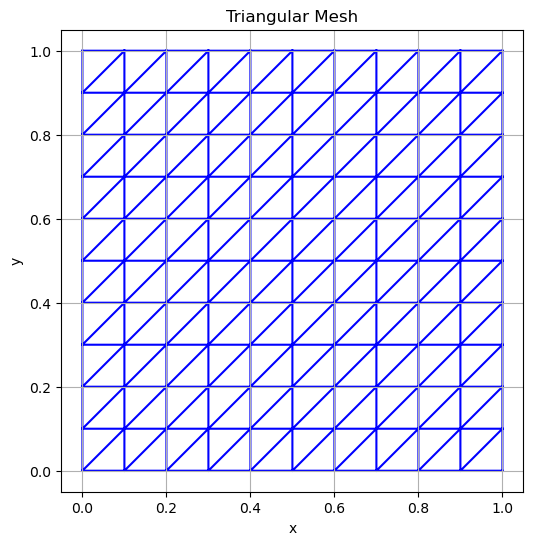

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# Grid settings
num_grids = 10
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)

points = np.vstack([X.ravel(), Y.ravel()]).T

point_indices = np.arange((num_grids + 1) ** 2).reshape((num_grids + 1), (num_grids + 1))

triangles = []

for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i+1]
        tr = point_indices[j+1, i+1]
        tl = point_indices[j+1, i]

        # Triangle 1: bottom-left, bottom-right, top-right
        triangles.append([bl, br, tr])

        # Triangle 2: bottom-left, top-right, top-left
        triangles.append([bl, tr, tl])

triangles = np.array(triangles)

triangulation = mtri.Triangulation(points[:, 0], points[:, 1], triangles)

# Plot
plt.figure(figsize=(6, 6))
plt.triplot(triangulation, color='blue')
plt.gca().set_aspect('equal')
plt.title("Triangular Mesh")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


# 3. FEM Applied to the Triangular Mesh to Solve 2D Poisson Equation (Constant Source Term):

**1. Mesh Generation**: We discretize the domain space: $\Omega \in [0,1]\times[0,1]$ into 2500 node points and make triangluar meshes out of them:

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D

# Grid settings
num_grids = 100
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)

points = np.vstack([X.ravel(), Y.ravel()]).T

point_indices = np.arange((num_grids + 1) ** 2).reshape((num_grids + 1), (num_grids + 1))

triangles = []

for i in range(num_grids):
    for j in range(num_grids):
        
        bl = point_indices[j, i]
        br = point_indices[j, i+1]
        tr = point_indices[j+1, i+1]
        tl = point_indices[j+1, i]

        # Triangle 1:
        triangles.append([bl, br, tr])

        # Triangle 2:
        triangles.append([bl, tr, tl])


triangles = np.array(triangles)



**2. Basis Functions**:
The basis functions are to be defined for each of the triangular meshes. For one particular triangluar subspace, there exist three of such basis functions ($\phi_0, \phi_1$ and $\phi_2$). For the basis function $\phi_0 = a_0x + b_0y + c_0$, we have:
$$
\begin{bmatrix}
x^0 & y^0 & 1\\
x^1 & y^1 & 1\\
x^2 & y^2 & 1
\end{bmatrix} \begin{bmatrix}
a_0 \\
b_0 \\
c_0
\end{bmatrix}
= \begin{bmatrix}
1 \\
0 \\
0
\end{bmatrix}
$$ where ($x^0,y^0$),($x^1,y^1$) and ($x^2,y^2$) are the coordinates of the node points/vertices of the given triangle.
and similar method is used to find coefficents for other two basis functions. 
Solving the above matrix equation gives the required coefficients $a_k, b_k$ and $c_k$.

In [ ]:
def basis_functions(coords):  
    A = np.ones((3, 3))
    A[:, 0:2] = coords  


    grads = np.zeros((3, 2))  # Each row: [a_i, b_i]. We will later realise that we won't actually need the c_i coefficients.

    for k in range(3):
        rhs = np.zeros(3)              
        rhs[k] = 1                     
        sol = np.linalg.solve(A, rhs)  
        grads[k, :] = sol[0:2]         
    
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area


**3. Stifness Matrix:**
The elements of the local stifness matrix is given by: 
$$
K_{ij}^t = \int_t\nabla\phi_i.\nabla\phi_j^Tds = \nabla\phi_i.\nabla\phi_j^T * (Area) = (a_ia_j+b_ib_j)\times Area
$$
where, "Area" is the area of the triangle t (being dealt in the moment in the for loop) given by half the determinant value of the matrix A defined above.

In [45]:

K = np.zeros((points.shape[0], points.shape[0]))  
F = np.zeros(points.shape[0])                     
 

for t in triangles:
    coords = points[t]
    
    grads, area = basis_functions(coords) 

    kt = grads @ grads.T * area
    ft = (area / 3) * np.ones(3)          

    for i in range(3):
        for j in range(3):
            global_i = t[i]
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]
    F[global_i] += ft[i]
    

**4. Boundary Conditions:**

In [ ]:
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]

# Final Boundary Conditions:
for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0

**5. Final Solution:**

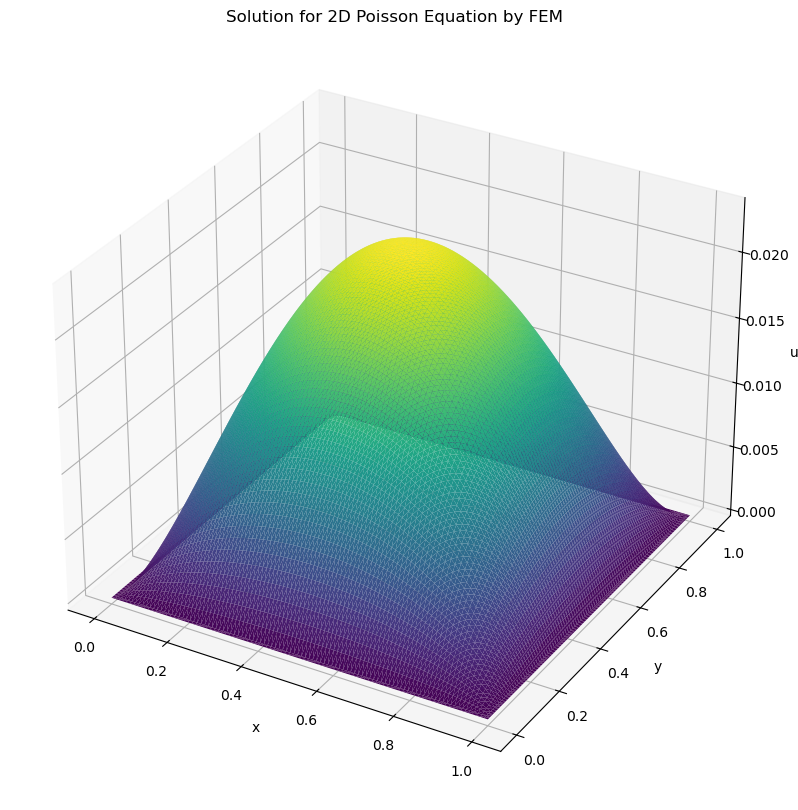

In [ ]:
u = np.linalg.solve(K, F)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u, cmap='viridis', edgecolor='none')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
ax.set_title('Solution to 2D Poisson Equation by FEM')

plt.show()

## 4. FEM on Sine-Based Source Term in 2D Poisson Equation:

We now try to solve the 2D Poisson Equation: $-\nabla^2u = f$ for when, $u = u(x,y)$ and $f(x,y) = sin(\pi x)sin(\pi y)$:

CPU computation time: 106.55 seconds
L2 Relative Error: 0.0000


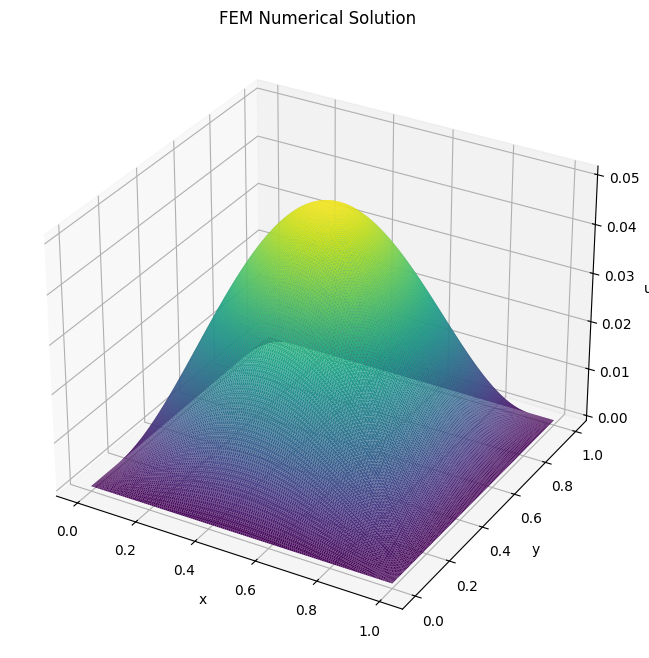

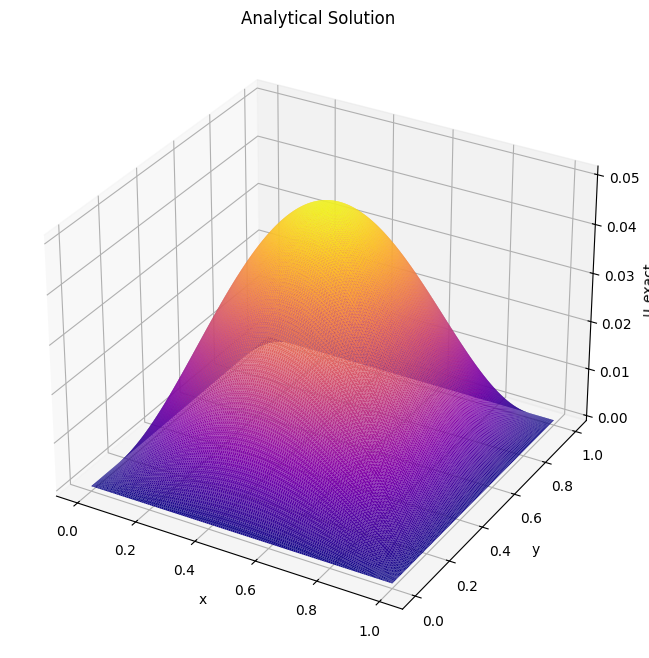

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import time

start_time = time.time()


# 1. Mesh Generation:
num_grids = 150
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T
point_indices = np.arange((num_grids + 1)**2).reshape((num_grids + 1, num_grids + 1))

triangles = []
for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i + 1]
        tr = point_indices[j + 1, i + 1]
        tl = point_indices[j + 1, i]
        triangles.append([bl, br, tr])
        triangles.append([bl, tr, tl])
triangles = np.array(triangles)

# 2. Basis Functions:
def basis_functions(coords):
    A = np.ones((3, 3))
    A[:, 0:2] = coords
    grads = np.zeros((3, 2))
    for k in range(3):
        rhs = np.zeros(3)
        rhs[k] = 1
        sol = np.linalg.solve(A, rhs)
        grads[k, :] = sol[0:2]
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area

# 3. Source term and analytical solution
def source_term(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def analytical_solution(x, y):
    return (1 / (2 * np.pi**2)) * np.sin(np.pi * x) * np.sin(np.pi * y)

# 4. Assembly of global matrices
K = np.zeros((points.shape[0], points.shape[0]))
F = np.zeros(points.shape[0])

for t in triangles:
    coords = points[t]
    grads, area = basis_functions(coords)
    kt = grads @ grads.T * area

    f_values = source_term(coords[:, 0], coords[:, 1])
    ft = f_values * (area / 3)

    for i in range(3):
        global_i = t[i]
        F[global_i] += ft[i]
        for j in range(3):
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]


# 5. Boundary Condition (u = 0 on boundary)
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]


for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0


# 6. Solution
u = np.linalg.solve(K, F)

# Timing End
end_time = time.time()
print(f"CPU computation time: {end_time - start_time:.2f} seconds")

# 7. Analytical solution and error
u_exact = analytical_solution(points[:, 0], points[:, 1])
error_l2 = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)
print(f"L2 Relative Error: {error_l2:.4f}")


# 8. Numerical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u, cmap='viridis', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
ax.set_title('FEM Numerical Solution')
plt.show()


# 9. Analytical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_exact, cmap='plasma', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u_exact')
ax.set_title('Analytical Solution')
plt.show()



## References:
1. NumPy Documentation: https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html
2. MatPlotLib Documentation: https://matplotlib.org/stable/api/tri_api.html
3. Larson, Mats & Bengzon, Fredrik. (2013). The Finite Element Method: Theory, Implementation, and Applications.
4. Reddy, J. N. (John N.). An Introduction to the Finite Element Method. McGraw-Hill, New York, 1993.